In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix
from sklearn.inspection import permutation_importance
import warnings
warnings.filterwarnings('ignore')

In [30]:
df= pd.read_csv("C:/Users/admin/OneDrive/Desktop/Datasets/WA_Fn-UseC_-Telco-Customer-Churn.csv")

In [31]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [32]:
df.head(5)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [33]:
#checking null values 
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [34]:
df['TotalCharges']=pd.to_numeric(df['TotalCharges'],errors='coerce')

In [35]:
#filling null values of the Total charges 
df['TotalCharges'].fillna(df['MonthlyCharges'], inplace=True)

0         29.85
1       1889.50
2        108.15
3       1840.75
4        151.65
         ...   
7038    1990.50
7039    7362.90
7040     346.45
7041     306.60
7042    6844.50
Name: TotalCharges, Length: 7043, dtype: float64

In [36]:
#converting churn yes, no into binary 0,1
df['Churn_Binary'] = (df['Churn'] == 'Yes').astype(int)

In [37]:
print(df.shape, df['Churn_Binary'].mean())

(7043, 22) 0.2653698707936959


In [38]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,Churn_Binary
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,0
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,No,No,No,One year,No,Mailed check,56.95,1889.50,No,0
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,0
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1


Exploratory Data Analysis

Business Question #1:What % of customers are churning

In [39]:
churn_rate = df['Churn'].value_counts(normalize=True) * 100
print(churn_rate)

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


Insights: So we have 70%+  of customers have churned, indicating a moderate imbalance. This suggests churn prediction is important but requires handling class imbalance carefully.

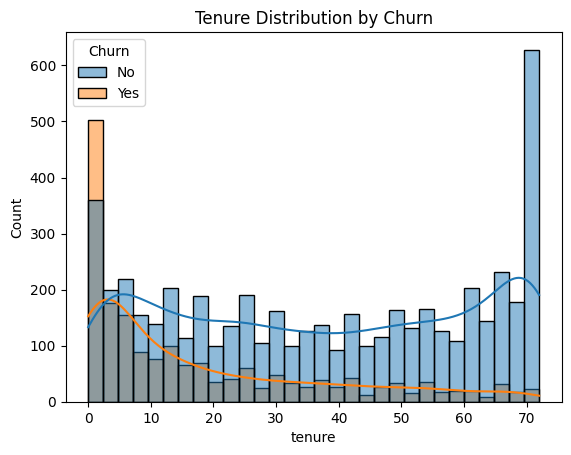

In [40]:
sns.histplot(data=df, x='tenure', hue='Churn', bins=30, kde=True)
plt.title("Tenure Distribution by Churn")
plt.show()

Insights: Customers with low tenure (early stage) are much more likely to churn, indicating onboarding and early engagement are critical.

Business Question #3: Does Contract Lenght protect against churn?

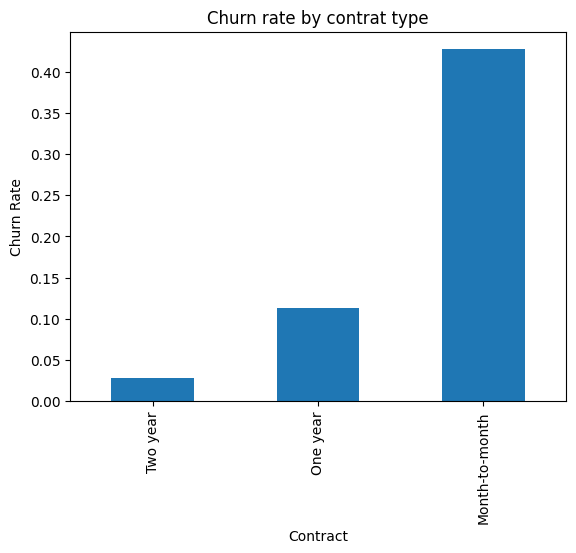

In [41]:
contract_churn= df.groupby('Contract')['Churn_Binary'].mean().sort_values()
contract_churn.plot(kind='bar')
plt.title("Churn rate by contrat type")
plt.ylabel("Churn Rate")
plt.show()

Inisghts: Customers on month-to-month contracts have significantly higher churn, while long-term contracts (1-2 years) greatly reduce churn risk

Business question #4: Which service features correalte with churn?

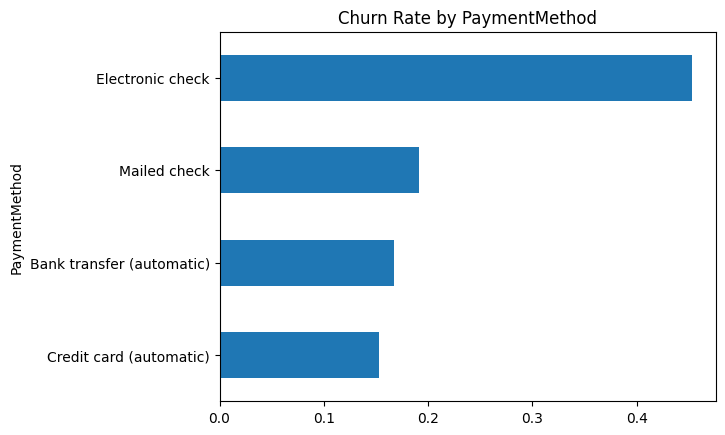

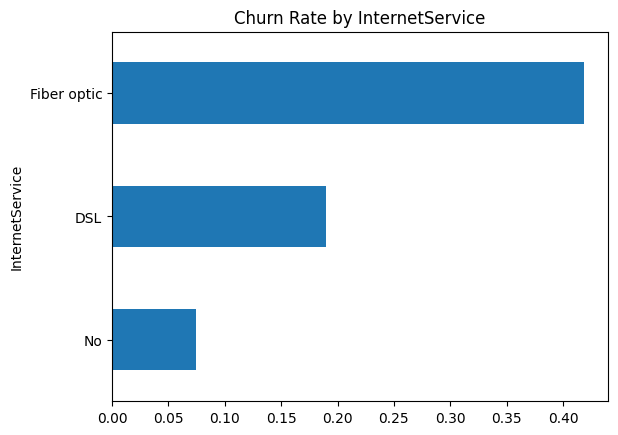

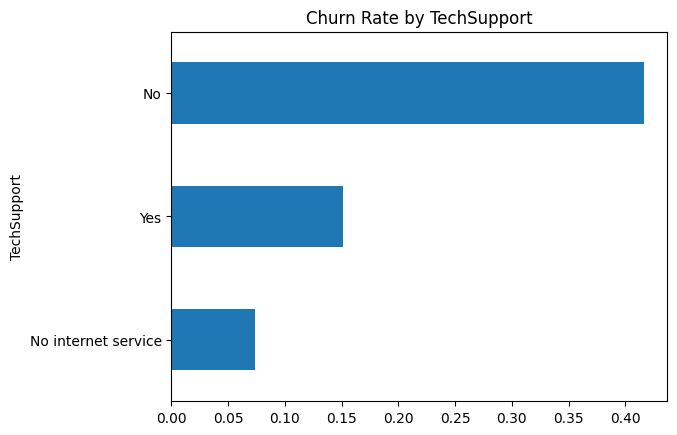

In [42]:
features=["PaymentMethod","InternetService","TechSupport"]
for col in features:
    churn_rate=df.groupby(col)['Churn_Binary'].mean().sort_values()
    churn_rate.plot(kind='barh')
    plt.title(f"Churn Rate by {col}")
    plt.show()

Insights: Electronic check users: higher churn
Fiber optic users: often higher churn (surprising!)
No tech support: higher churn
Strong interpretation:
Lack of support services and certain payment methods are associated with higher churn, suggesting friction in customer experience.

Business question #5: Are churners paying more or less?

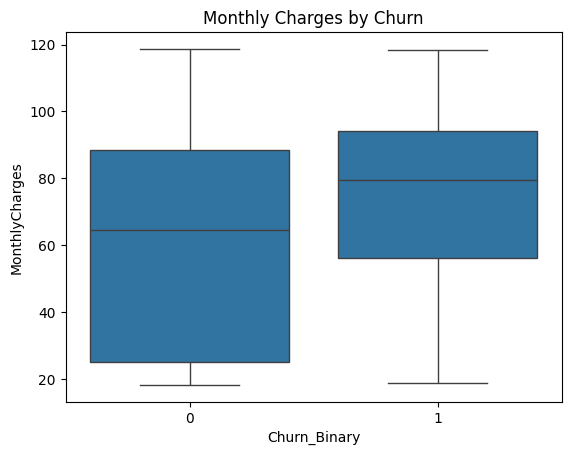

In [43]:
sns.boxplot(x='Churn_Binary', y='MonthlyCharges', data=df)
plt.title("Monthly Charges by Churn")
plt.show()

Since in earliere insights we have ~73% No, ~27% Yes in this dataset. If we skip this and do the model trainign and other steps. model learns to predict "No" for everyone and still looks good. So We have ad opetion hadle this imablance

In [44]:
model=RandomForestClassifier(class_weight='balanced', random_state=42)

In [46]:
# ── Check what columns actually exist ────────────────────────────────────────
print(df.columns.tolist())

['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn', 'Churn_Binary']


In [47]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

# ── Encode categoricals in-place ─────────────────────────────────────────────
df_model = df.copy()

cat_cols = ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
            'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
            'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
            'PaperlessBilling', 'PaymentMethod']

le = LabelEncoder()
for col in cat_cols:
    df_model[col] = le.fit_transform(df_model[col])

# ── Features & target ─────────────────────────────────────────────────────────
feature_cols = ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges',
                'gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
                'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
                'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
                'PaperlessBilling', 'PaymentMethod']

X = df_model[feature_cols]
y = df_model['Churn_Binary']

# ── Split ─────────────────────────────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# ── Scale ─────────────────────────────────────────────────────────────────────
scaler  = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

print(f"Train size : {X_train.shape}")
print(f"Test size  : {X_test.shape}")
print(f"Churn rate in train : {y_train.mean()*100:.1f}%")
print(f"Churn rate in test  : {y_test.mean()*100:.1f}%")
print("Ready to train")

Train size : (5634, 19)
Test size  : (1409, 19)
Churn rate in train : 26.5%
Churn rate in test  : 26.5%
Ready to train


In [53]:
#Fill NaNs
df_model[feature_cols] = df_model[feature_cols].fillna(df_model[feature_cols].median())

print("NaNs remaining:", df_model[feature_cols].isnull().sum().sum())
print("Clean — ready to split")

NaNs remaining: 0
Clean — ready to split


In [52]:
# Check where NaNs are 
print("NaNs per column:")
print(df_model[feature_cols].isnull().sum()[df_model[feature_cols].isnull().sum() > 0])

NaNs per column:
Series([], dtype: int64)


In [57]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import numpy as np

#  Features & target 
X = df_model[feature_cols].copy()
y = df_model['Churn_Binary']

# Fill NaNs right here before anything else 
X = X.fillna(X.median())

#Confirm clean 
print("NaNs in X:", X.isnull().sum().sum())

# Split 
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scale
scaler  = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

print(f"Train size : {X_train.shape}")
print(f"Test size  : {X_test.shape}")
print(f"Churn rate in train : {y_train.mean()*100:.1f}%")
print(f"Churn rate in test  : {y_test.mean()*100:.1f}%")
print("Ready to train")

NaNs in X: 0
Train size : (5634, 19)
Test size  : (1409, 19)
Churn rate in train : 26.5%
Churn rate in test  : 26.5%
Ready to train


In [58]:
results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    report = classification_report(y_test, y_pred, output_dict=True)

    results[name] = {
        'AUC'      : round(roc_auc_score(y_test, y_prob), 4),
        'Precision': round(report['1']['precision'], 4),
        'Recall'   : round(report['1']['recall'], 4),
        'F1-Score' : round(report['1']['f1-score'], 4),
        'Accuracy' : round(report['accuracy'], 4),
    }
    print(f" {name} trained")

 Logistic Regression trained
 Random Forest trained
 Gradient Boosting trained


In [60]:
#Output of each models
results_df = pd.DataFrame(results).T.sort_values('AUC', ascending=False)
results_df.index.name = 'Model'
print(results_df.to_string())

                        AUC  Precision  Recall  F1-Score  Accuracy
Model                                                             
Gradient Boosting    0.8407     0.6610  0.5214    0.5830    0.8020
Logistic Regression  0.8396     0.5059  0.7968    0.6189    0.7395
Random Forest        0.8237     0.6263  0.4706    0.5374    0.7850


Chosen model: Logistic Regression
Reason: In a churn problem, missing an actual churner (False Negative) costs
the business real revenue. Logistic Regression catches 80% of churners vs
52% for Gradient Boosting — making it the better business choice despite
similar AUC scores.

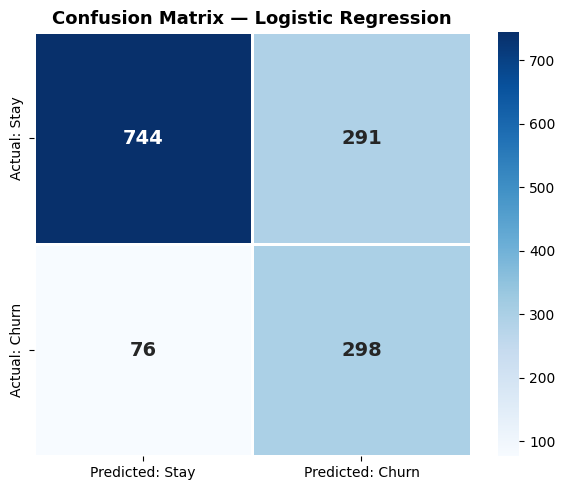


  True Negatives  (Correctly predicted Stay)    : 744
  True Positives  (Correctly caught Churners)   : 298
  False Positives (Said churn, actually stayed) : 291  ← wasted retention budget
  False Negatives (Missed churners)             : 76  ← lost revenue

  Of every 100 churners, we catch 80 of them.


In [61]:
best_name   = 'Logistic Regression'
best_model  = models[best_name]
y_pred_best = best_model.predict(X_test)

cm = confusion_matrix(y_test, y_pred_best)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['Predicted: Stay', 'Predicted: Churn'],
            yticklabels=['Actual: Stay',    'Actual: Churn'],
            annot_kws={'size': 14, 'weight': 'bold'},
            linewidths=1, linecolor='white')
ax.set_title(f'Confusion Matrix — {best_name}', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"\n  True Negatives  (Correctly predicted Stay)    : {tn:,}")
print(f"  True Positives  (Correctly caught Churners)   : {tp:,}")
print(f"  False Positives (Said churn, actually stayed) : {fp:,}  ← wasted retention budget")
print(f"  False Negatives (Missed churners)             : {fn:,}  ← lost revenue")
print(f"\n  Of every 100 churners, we catch {tp/(tp+fn)*100:.0f} of them.")

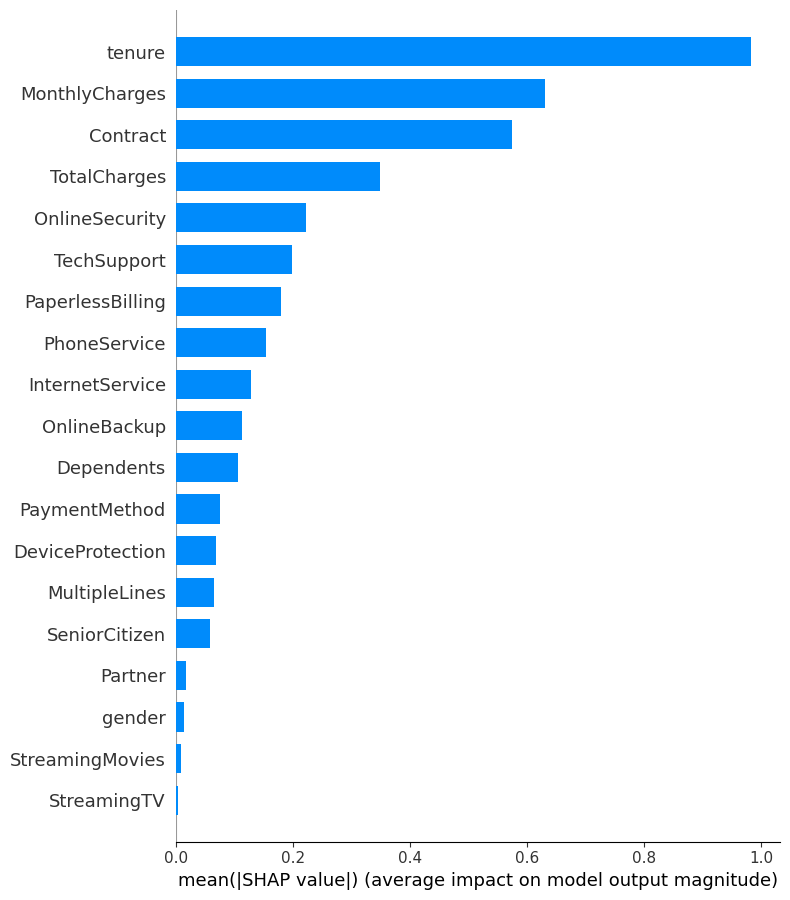

In [62]:
import shap

# Use Logistic Regression with LinearExplainer
explainer   = shap.LinearExplainer(best_model, X_train)
shap_values = explainer.shap_values(X_test)

# Global feature importance
shap.summary_plot(shap_values, X_test,
                  feature_names=feature_cols,
                  plot_type='bar',
                  show=True)

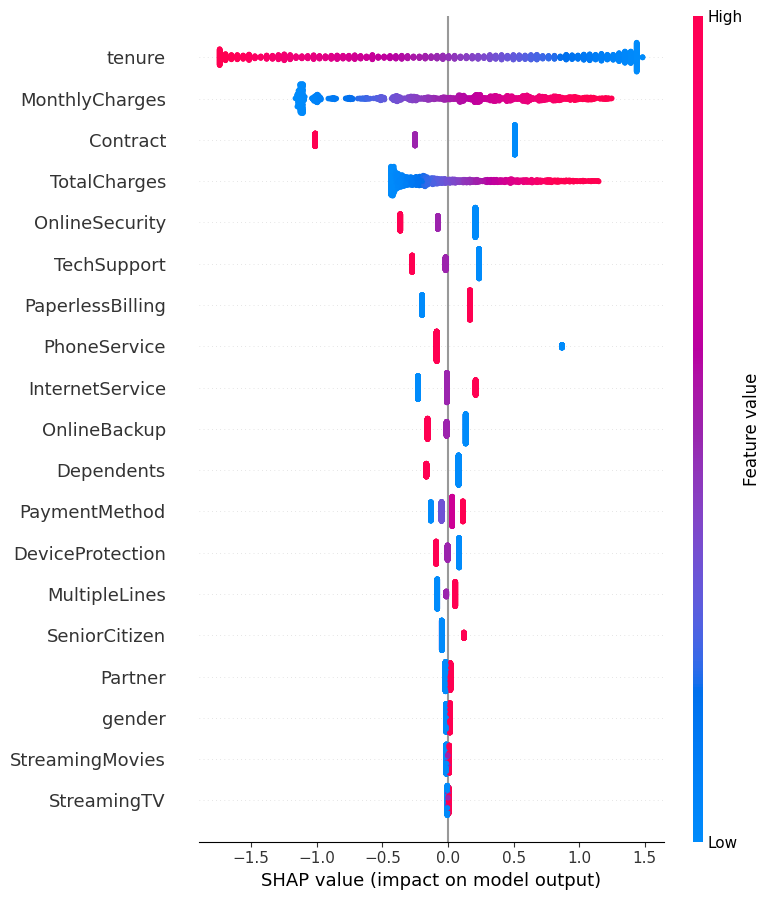

In [63]:
shap.summary_plot(shap_values, X_test,
                  feature_names=feature_cols,
                  show=True)

## SHAP Analysis — What Drives Churn?

**How to read this chart:**
- Right side (positive SHAP) = pushes customer TOWARD churning
- Left side (negative SHAP) = pushes customer AWAY from churning
- Red dots = high feature value, Blue dots = low feature value

**Key findings:**

1. **Tenure** — Most important feature by far
   - Blue (low tenure) on the RIGHT = new customers churn most
   - Red (high tenure) on the LEFT = long-term customers stay

2. **MonthlyCharges** — Second most important
   - Red (high charges) on the RIGHT = expensive plans drive churn
   - Customers paying more are more likely to leave

3. **Contract** — Strong protective factor
   - Red (long contract) on the LEFT = 2-year contracts retain customers
   - Blue (month-to-month) on the RIGHT = highest churn risk

4. **TotalCharges** — Correlated with tenure: High total charges (red) pull LEFT = loyal long-term spenders stay

5. **OnlineSecurity & TechSupport:** Customers WITHOUT these services churn more

**Business Recommendation:**
Target new customers (low tenure) on month-to-month contracts
with high monthly charges and  offer them a contract upgrade discount
and add OnlineSecurity or TechSupport to their plan.

In [65]:
# ── Score every customer with churn probability ───────────────────────────────
X_all = df_model[feature_cols].fillna(df_model[feature_cols].median())
X_all_scaled = scaler.transform(X_all)

df['Churn_Probability']  = best_model.predict_proba(X_all_scaled)[:, 1].round(4)
df['Churn_Predicted']    = best_model.predict(X_all_scaled)
df['Churn_Predicted']    = df['Churn_Predicted'].map({1: 'Yes', 0: 'No'})

#Risk tier 
df['Risk_Tier'] = pd.cut(df['Churn_Probability'],
                          bins=[0, 0.25, 0.50, 0.70, 1.0],
                          labels=['Low', 'Medium', 'High', 'Critical'])

#Revenue at risk
df['Revenue_At_Risk'] = (df['MonthlyCharges'] * df['Churn_Probability'] * 12).round(2)

#Retention action
def retention_action(row):
    if row['Risk_Tier'] == 'Critical':
        return 'Immediate call — offer 2-year contract discount'
    elif row['Risk_Tier'] == 'High':
        return 'Send retention offer — add TechSupport bundle'
    elif row['Risk_Tier'] == 'Medium':
        return 'Loyalty email — highlight service value'
    else:
        return 'Standard engagement — quarterly check-in'

df['Retention_Action'] = df.apply(retention_action, axis=1)

print(df[['customerID', 'Churn_Probability', 'Risk_Tier',
          'Revenue_At_Risk', 'Retention_Action']].head(10))

   customerID  Churn_Probability Risk_Tier  Revenue_At_Risk  \
0  7590-VHVEG             0.7726  Critical           276.75   
1  5575-GNVDE             0.1449       Low            99.02   
2  3668-QPYBK             0.5641      High           364.52   
3  7795-CFOCW             0.0858       Low            43.55   
4  9237-HQITU             0.8390  Critical           711.81   
5  9305-CDSKC             0.9010  Critical          1077.42   
6  1452-KIOVK             0.7501  Critical           802.01   
7  6713-OKOMC             0.5663      High           202.17   
8  7892-POOKP             0.7993  Critical          1005.20   
9  6388-TABGU             0.0337       Low            22.71   

                                  Retention_Action  
0  Immediate call — offer 2-year contract discount  
1         Standard engagement — quarterly check-in  
2    Send retention offer — add TechSupport bundle  
3         Standard engagement — quarterly check-in  
4  Immediate call — offer 2-year contract

In [68]:
#Export for Power BI
export_cols = ['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
               'tenure', 'Contract', 'InternetService', 'PaymentMethod',
               'MonthlyCharges', 'TotalCharges', 'Churn',
               'Churn_Probability', 'Churn_Predicted', 'Risk_Tier',
               'Revenue_At_Risk', 'Retention_Action']

df[export_cols].to_csv('churn_scored.csv', index=False)

#Summary stats 
print(f"Total customers     : {len(df):,}")
print(f"Critical risk       : {(df['Risk_Tier']=='Critical').sum():,}")
print(f"High risk           : {(df['Risk_Tier']=='High').sum():,}")
print(f"Total revenue at risk: ${df['Revenue_At_Risk'].sum():,.0f}")
print(f"\nchurn_scored.csv exported ready for Power BI")

Total customers     : 7,043
Critical risk       : 1,789
High risk           : 1,124
Total revenue at risk: $2,556,135

churn_scored.csv exported ready for Power BI
